In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
data = pd.read_excel('data/Pyrolysis_Data 6-16_Reduced.xlsx')

data.describe()

,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
count,6669,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,...,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000,6669.000000
mean,2015-12-22 07:16:59.470808576,52086.607262,8712.582010,8287.932362,8842.522833,8603.680748,8444.248226,8865.866092,4297.905730,4452.905547,...,617.811929,622.511101,831.648208,836.780286,835.400132,836.319523,837.300782,837.903612,1027.474983,837.910011
min,2015-11-06 00:00:00,45736.531250,7466.118164,7110.184570,7652.420410,7561.086914,7439.499512,7731.586426,4147.067871,4204.664050,...,603.491333,611.425110,804.398743,809.329590,810.840485,812.086029,811.762329,811.068130,980.803802,813.534363
25%,2015-11-29 03:40:00.007000064,52080.425781,8674.464844,8250.759766,8816.666992,8557.800781,8409.102539,8819.564453,4277.095703,4445.440693,...,614.694580,620.329590,830.853425,836.122177,834.470825,835.493164,836.341479,836.836578,1019.737488,837.743379
50%,2015-12-22 07:19:27.335000064,52136.097656,8731.911133,8286.455078,8849.289062,8605.119141,8459.644902,8884.833008,4288.175293,4462.412109,...,618.976257,622.934143,831.628510,836.826157,835.474991,836.345734,837.407837,838.015167,1029.567841,837.979076
75%,2016-01-14 10:54:36.375000064,52197.140625,8777.038086,8320.266851,8883.692383,8672.966798,8504.736328,8927.785156,4300.790039,4474.368161,...,620.939880,624.776917,832.425751,837.532196,836.445328,837.252701,838.400406,839.075317,1035.154907,838.240967
max,2016-02-06 14:25:05.950000,53489.472656,9053.129883,9278.496829,9080.204688,8854.346362,8805.973330,9129.166016,4469.789062,4630.651488,...,625.199951,629.285583,846.023840,865.560687,845.728282,843.780106,846.446014,850.595634,1045.856140,841.106018
std,NaN,464.738337,121.623591,120.638306,95.786130,107.469695,112.196548,106.172983,40.376338,42.363111,...,3.940449,2.917192,1.910854,2.236806,1.922875,1.811575,2.094034,2.244648,10.038618,1.285605


In [4]:
def plot_data(data):

    fig = plt.figure(figsize=(10, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for col in data.iloc[:, 1:].columns:

        axs0.plot(np.asarray(data.iloc[:, 0]), np.asarray(data[col]))


    axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', rotation=45)

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)


    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

In [5]:
def plot_clusters(data, basis_data = None, dr_model = None):
    scaler = MinMaxScaler(feature_range=(-1, 1))

    try:
        
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 0:]))
    
    except:
        scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 1:]))

    scaled_data.head()

    # Project data in 2D
    if dr_model is None:
        dr_model = pacmap.PaCMAP(
            n_neighbors=10,
            MN_ratio=5,
            FP_ratio=20,
            # distance=euclidean,
            lr=1.0,
            apply_pca=True,
            verbose=False,
            intermediate=False,
            save_tree=True
            )

        reduced_data = dr_model.fit_transform(scaled_data.values, )
    
    else:
        reduced_data = dr_model.transform(scaled_data.values, basis = basis_data.iloc[:, 1:].values)


    # get clusters        
    cl_model = hdbscan.HDBSCAN(
        min_samples=int(np.floor(scaled_data.shape[0] / 50)))
    labels = cl_model.fit_predict(reduced_data)

    clustered_df = pd.DataFrame(
        data={
            'd0': reduced_data[:, 0],
            'd1': reduced_data[:, 1],
            # 'd2': reduced_data[:, 2],
            'label': labels
        })

    clustered_df['target'] = data.iloc[:, -1]

    fig1 = plt.figure(figsize=(5, 5))

    clustered_df_denoised = clustered_df.loc[clustered_df.label != -1]

    axs1 = fig1.add_subplot(111)  #projection='3d')
    print('Preparing plot...')

    colors = clustered_df_denoised['label']
    cmap='Set3'

    axs1.scatter(
        clustered_df_denoised['d0'],
        clustered_df_denoised['d1'],
        #this_cluster['d2'],
        s=10,
        cmap=cmap,
        c=colors,#clustered_df_denoised['label'],  #data.iloc[:, 1]
        # marker='o',
        edgecolors='k',
        # alpha=0.9,
        linewidths=0.1,
        # label=label
        )

    noise_df = clustered_df.loc[clustered_df.label == -1]

    axs1.scatter(
                noise_df['d0'],
                noise_df['d1'],
                #this_cluster['d2'],
                s=7,
                cmap=cmap,
                c='k',  #data.iloc[:, 1]
                # marker='o',
                edgecolors='k',
                alpha=0.4,
                linewidths=0.1,
    )

    axs1.set_xlabel(r'$ \rm PaCAMP\ 0$', labelpad = 10, fontsize='x-large')
    axs1.set_ylabel(r'$ \rm PaCAMP\ 1$', labelpad = 10, fontsize='x-large')

    axs1.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large')

    axs1.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs1.spines[ax].set_linewidth(1)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return dr_model, clustered_df.label
 

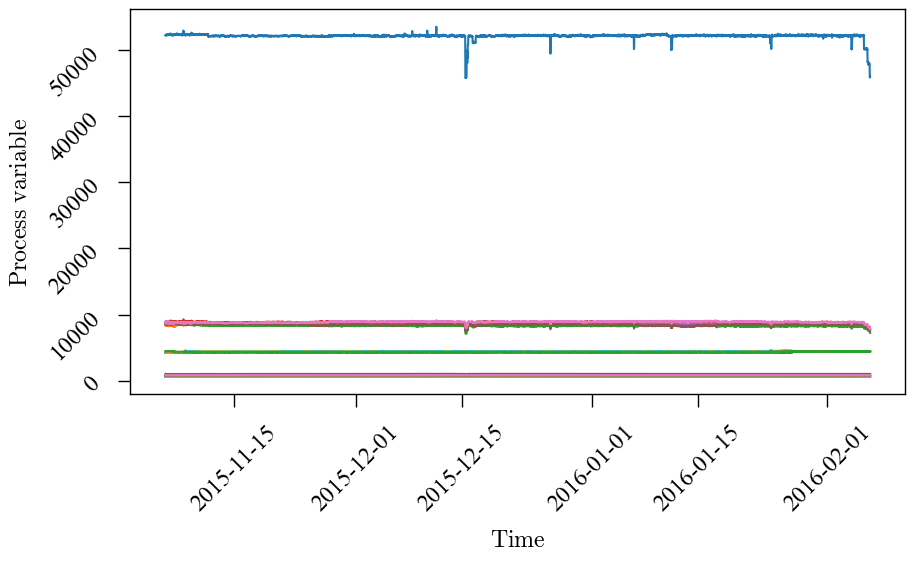

In [7]:
plot_data(data)

/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35518/1858017777.py:74: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs1.scatter(


Preparing plot...


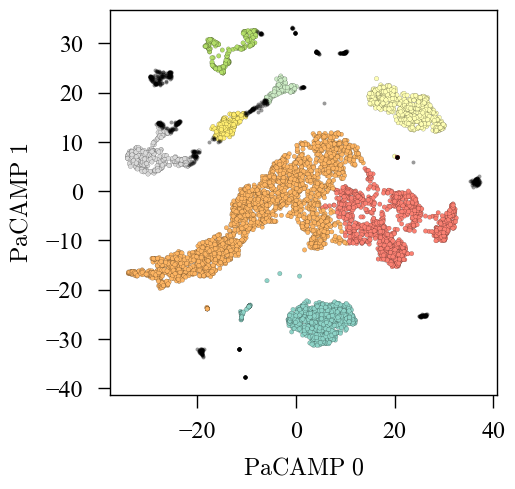

In [8]:
dr_model, labels = plot_clusters(data)

In [9]:
labels

0      -1
1       4
2       4
3       4
4       4
       ..
6664   -1
6665   -1
6666   -1
6667   -1
6668   -1
Name: label, Length: 6669, dtype: int64

In [10]:
from imblearn.under_sampling import CondensedNearestNeighbour  
cnn = CondensedNearestNeighbour(random_state=42, n_neighbors=5)

filtered_data = cnn.fit_resample(data.iloc[:, 1:], labels) 


filtered_data[0].head()

,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,11FC05043PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
0,52334.434830,8721.440606,8368.250147,8878.135943,8740.806348,8567.787356,8804.799820,4282.518897,4461.865622,4358.620595,...,612.794433,620.628806,830.187662,835.198673,837.042422,836.549725,833.852125,837.546430,1010.509484,837.686971
1,52221.634263,8326.643312,8514.593137,8772.479316,8702.662279,8725.061214,8925.859148,4231.776051,4235.679965,4331.376363,...,611.155410,617.949135,835.685702,832.775546,837.579875,835.185782,837.532533,840.083022,1014.203860,838.564984
2,52200.328842,8273.890963,8515.235562,8786.784298,8692.363442,8774.243705,8967.026779,4227.987909,4236.520722,4338.350699,...,612.785978,619.107429,833.482934,828.335641,835.280010,834.854151,842.489960,846.319539,1011.952702,838.397351
3,52240.599403,8315.588421,8502.105429,8762.184962,8694.639345,8768.796221,8997.852215,4226.130267,4222.527552,4336.756831,...,610.812614,617.410995,833.344771,834.037237,838.906332,835.595273,838.255026,839.087380,1013.971608,837.788338
4,52318.774072,8446.983129,8516.745744,8866.969366,8683.478488,8686.906777,8888.253571,4251.383802,4450.131179,4330.709232,...,614.090468,621.167742,833.444667,829.325640,833.859343,835.984162,839.180486,840.513976,1010.599067,838.129291


Preparing plot...


/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35518/1858017777.py:74: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs1.scatter(


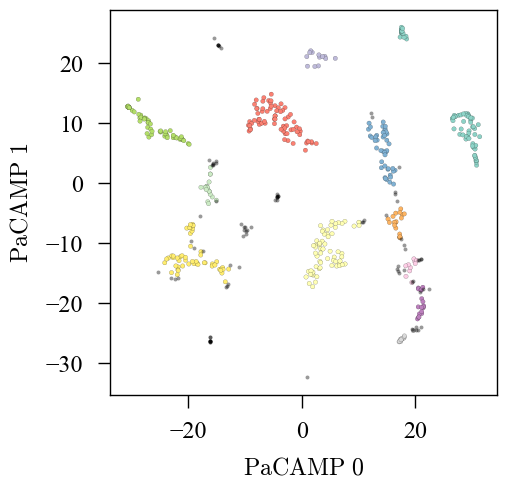

In [11]:
dr_model, labels = plot_clusters(data = filtered_data[0].dropna())#, basis_data=data, dr_model=dr_model)

In [13]:
def plot_window(data, lb, ub):

    fig = plt.figure(figsize=(5, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for col in data.iloc[:, 1:].columns:

        axs0.plot(np.asarray(data.iloc[lb:ub, 0]), np.asarray(data[col])[lb:ub])


    axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', rotation=45)

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

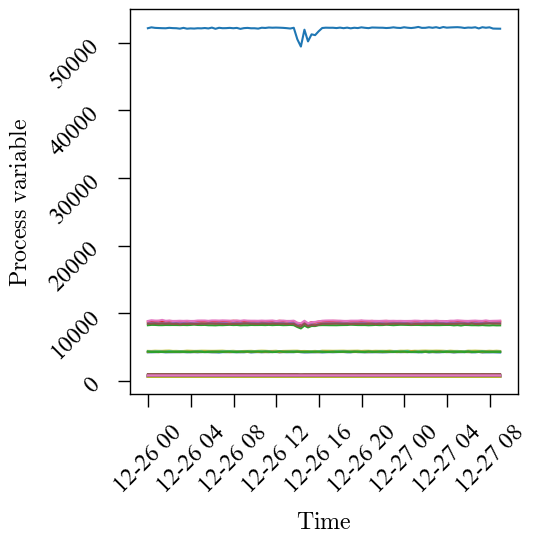

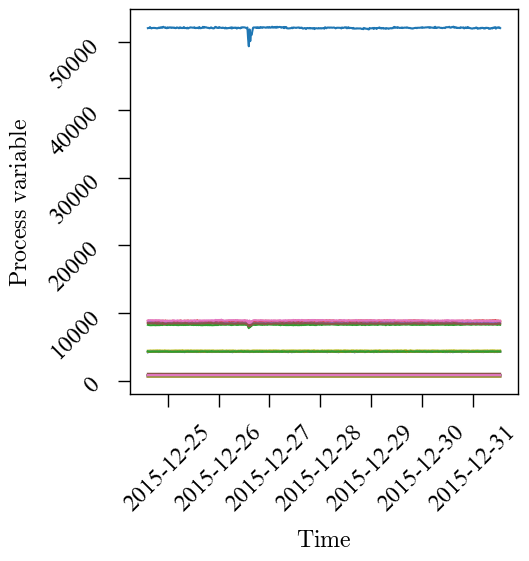

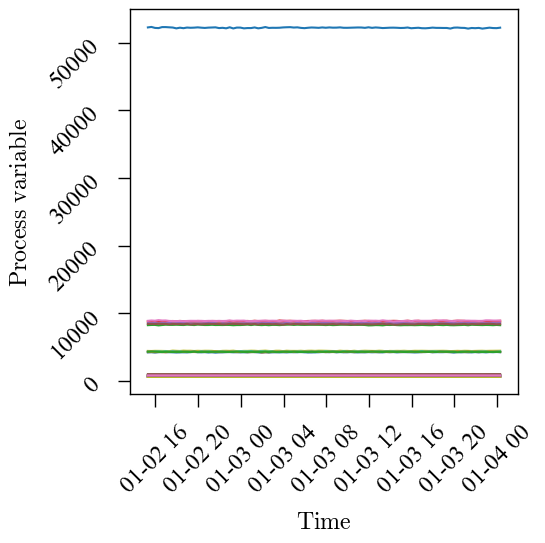

In [27]:
windows = [
    (3600, 3700),
    (3500, 4000), 
    (4150, 4250)
]

for window in windows:
    plot_window(data, window[0], window[1])